# Лабораторная работа №3

**Валюта:** Бразильский реал  
**Период:** 01.01.2006 – 31.12.2025  
**Файл:** Бразильский реал.xlsx

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma
import warnings


warnings.filterwarnings("ignore", message="Workbook contains no default style")

# Загружаем файл с сайта ЦБ РФ
df = pd.read_excel(
    'Бразильский реал.xlsx',
    sheet_name='RC'
)

# Правильно преобразуем колонку с датой
df['data'] = pd.to_datetime(df['data'], dayfirst=True, errors='coerce')

# Переименовываем колонки для удобства
df = df.rename(columns={'data': 'Дата', 'curs': 'Курс'})

df = df.dropna().sort_values('Дата').reset_index(drop=True)

dates = df['Дата']
rates = df['Курс'].values.astype(float)

n = len(rates)
print(f"Количество наблюдений n = {n}")
print(f"Период: {dates.iloc[0].date()} – {dates.iloc[-1].date()}")
print(f"Валюта: {df.get('cdx', pd.Series(['Бразильский реал'])).iloc[0]}")
print(f"Пример курса: {rates[0]:.4f} (дата: {dates.iloc[0].date()})")

Количество наблюдений n = 4003
Период: 2006-01-01 – 2025-12-31
Валюта: Бразильский реал
Пример курса: 12.2720 (дата: 2006-01-01)


## Пункт 2. Оценки математического ожидания и дисперсии

In [54]:
X_bar = np.mean(rates)
D_X = np.sum((rates - X_bar)**2) / n

print(f"¯X = {X_bar:.4f}")
print(f"DX = {D_X:.4f}")

¯X = 16.3589
DX = 6.4194


## Пункт 5. Проверка гипотезы о распределении Парето

In [55]:
# Метод моментов
alpha_mom = 2 * D_X / (D_X - X_bar**2)
x0_mom = (alpha_mom - 1) * X_bar

print(f"Метод моментов: alpha = {alpha_mom:.4f}, x0 = {x0_mom:.4f}")

if alpha_mom > 0 and x0_mom > 0 and x0_mom < np.min(rates):
    alpha = alpha_mom
    x0 = x0_mom
    method = "метод моментов"
else:
    # Метод максимального правдоподобия
    x0 = np.min(rates)
    alpha = n / np.sum(np.log(rates / x0))
    method = "метод максимального правдоподобия"

print(f"Использован {method}")
print(f"α = {alpha:.4f}, x0 = {x0:.4f}")

# KS-тест
def pareto_cdf(x):
    return stats.pareto.cdf(x, b=alpha, loc=x0, scale=1)

ks_stat, p_value = stats.kstest(rates, pareto_cdf)
print(f"KS-тест: statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")
if p_value > 0.05:
    print("Гипотеза Парето НЕ отвергается на уровне 5%")
else:
    print("Гипотеза Парето отвергается")

Метод моментов: alpha = -0.0492, x0 = -17.1630
Использован метод максимального правдоподобия
α = 2.0939, x0 = 10.0473
KS-тест: statistic = 0.8428, p-value = 0.0000
Гипотеза Парето отвергается


## Пункт 6. Экстремальные значения по годам + вероятность превышения в 2026 году

In [56]:
df['year'] = dates.dt.year
yearly_max = df.groupby('year')['Курс'].max()
m = len(yearly_max)
x_max = yearly_max.values
overall_max = np.max(x_max)

print(f"Максимумы по годам (m = {m})")
print("Годы в данных:", sorted(yearly_max.index.tolist()))
print(f"Общий максимум за все годы = {overall_max:.2f}")

# Упорядочиваем по убыванию
x_max_sorted = np.sort(x_max)[::-1]

# Адаптивная оценка Хилла ξ
k = min(10, m - 1) if m > 1 else 1
G_k = (1 / k) * np.sum(np.log(x_max_sorted[:k] / x_max_sorted[k]))
xi = 1 / G_k
print(f"ξ (Hill, k={k}) = {xi:.4f}")

if m < 20:
    print("Внимание: в данных только", m, "лет вместо 20. Результаты приближённые!")

if xi > 0.5:
    mu = 0
    sigma = 1
    print("ξ > 0.5 → принудительно μ=0, σ=1")
else:
    X_max_bar = np.mean(x_max)
    D_Xmax = np.sum((x_max - X_max_bar)**2) / m
    term1 = gamma(1 - 2*xi) - gamma(1 - xi)**2
    sigma = np.sqrt(D_Xmax * xi**2 / term1)
    term2 = gamma(1 - xi) - 1
    mu = X_max_bar - (sigma / xi) * term2
    print(f"μ = {mu:.4f}, σ = {sigma:.4f}")

# Вероятность превышения на 15% в 2026 году
z = 1.15 * overall_max
if xi <= 0:
    prob = np.exp(-np.exp(-(z - mu) / sigma))
else:
    arg = 1 + xi * (z - mu) / sigma
    prob = np.exp(-arg**(-1 / xi)) if arg > 0 else 0

print(f"P(M_2026 > 1.15 × max) = {1 - prob:.6f} ({(1-prob)*100:.2f}%)")

Максимумы по годам (m = 20)
Годы в данных: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Общий максимум за все годы = 98.05
ξ (Hill, k=10) = 3.5411
ξ > 0.5 → принудительно μ=0, σ=1
P(M_2026 > 1.15 × max) = 0.168162 (16.82%)


## Пункт 7. 30-летний уровень стоимости валюты

In [57]:
p = 1 - 1/25
if xi <= 0:
    level = mu - sigma * np.log(-np.log(p))
else:
    level = mu + (sigma / xi) * ((-np.log(p))**(-xi) - 1)
print(f"30-летний уровень (return level) = {level:.4f}")

30-летний уровень (return level) = 23432.2074


## Пункты 8–10. Графики

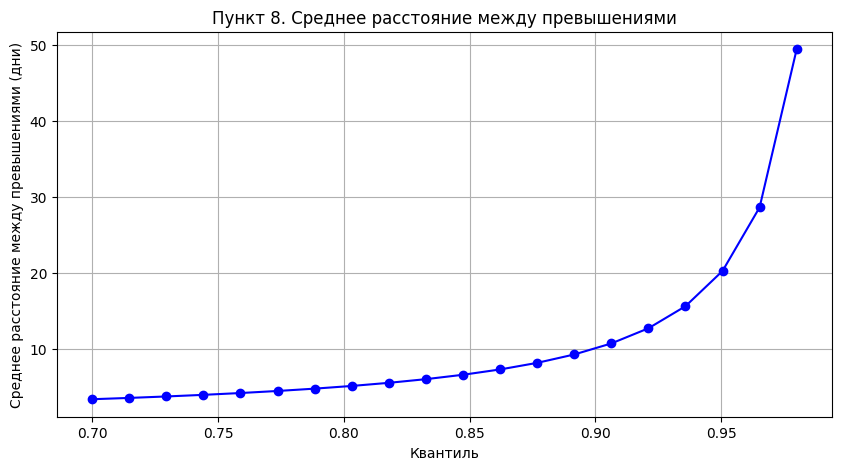

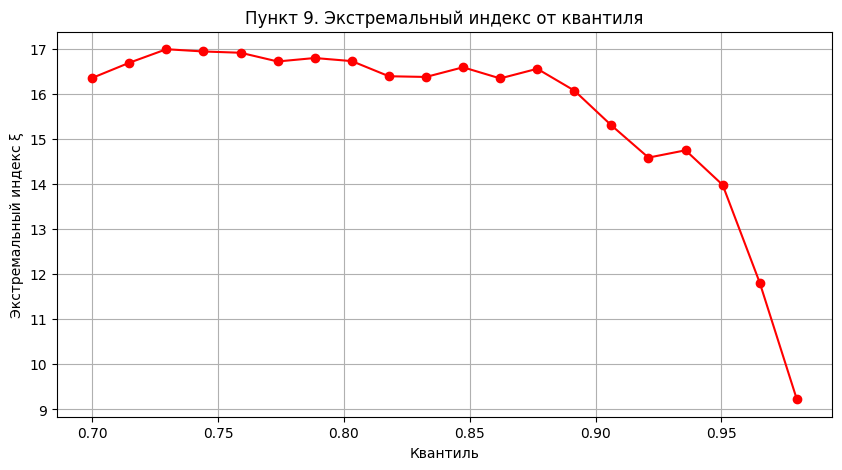

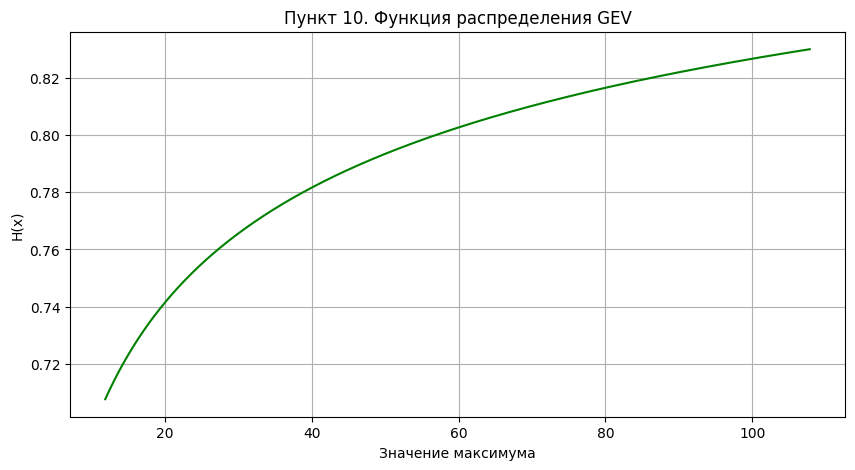

In [58]:
quantiles = np.linspace(0.70, 0.98, 20)
mean_distances = []
extreme_indices = []

for q in quantiles:
    u = np.quantile(rates, q)
    num_ex = np.sum(rates > u)
    mean_dist = n / num_ex if num_ex > 0 else np.nan
    mean_distances.append(mean_dist)
    
    k_q = int((1 - q) * n)
    if k_q > 1:
        top = np.sort(rates)[-k_q:]
        G = np.mean(np.log(top / top[0]))
        xi_q = 1 / G if G != 0 else np.nan
        extreme_indices.append(xi_q)
    else:
        extreme_indices.append(np.nan)

# График 8
plt.figure(figsize=(10, 5))
plt.plot(quantiles, mean_distances, 'bo-')
plt.xlabel('Квантиль')
plt.ylabel('Среднее расстояние между превышениями (дни)')
plt.title('Пункт 8. Среднее расстояние между превышениями')
plt.grid(True)
plt.show()

# График 9
plt.figure(figsize=(10, 5))
plt.plot(quantiles, extreme_indices, 'ro-')
plt.xlabel('Квантиль')
plt.ylabel('Экстремальный индекс ξ')
plt.title('Пункт 9. Экстремальный индекс от квантиля')
plt.grid(True)
plt.show()

# График 10 — GEV CDF
x_plot = np.linspace(np.min(x_max)*0.9, np.max(x_max)*1.1, 500)
if xi <= 0:
    cdf_gev = np.exp(-np.exp(-(x_plot - mu) / sigma))
else:
    arg = 1 + xi * (x_plot - mu) / sigma
    cdf_gev = np.exp(-arg**(-1 / xi))
plt.figure(figsize=(10, 5))
plt.plot(x_plot, cdf_gev, 'g-')
plt.xlabel('Значение максимума')
plt.ylabel('H(x)')
plt.title('Пункт 10. Функция распределения GEV')
plt.grid(True)
plt.show()

## Пункты 11–12. Value-at-Risk (GEV и GPD)

**Объём инвестиций = 2 000 000 ед.**

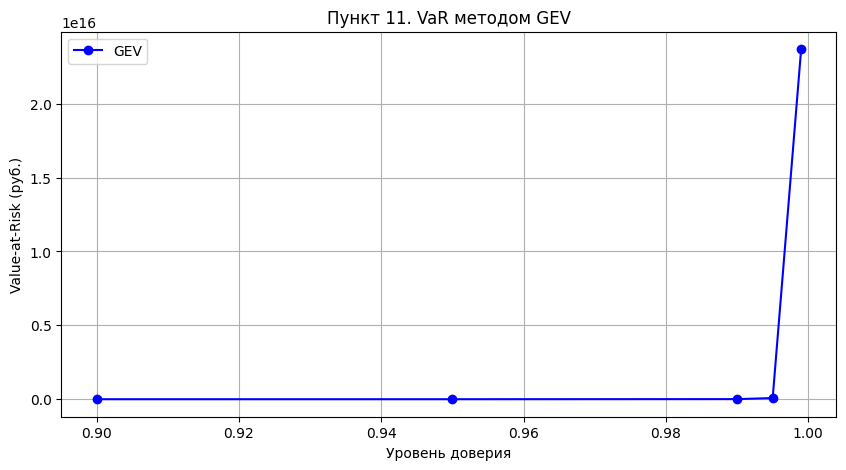

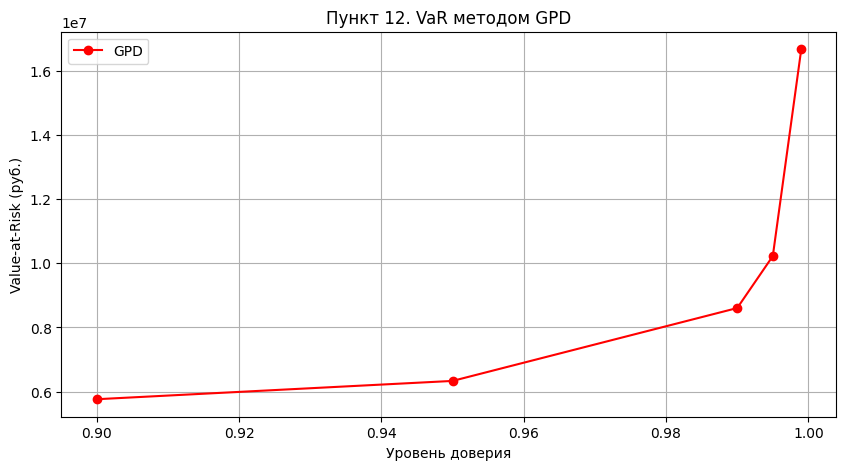

In [59]:
investment = 2_000_000
conf_levels = np.array([0.90, 0.95, 0.99, 0.995, 0.999])

# 11. Метод GEV (на основе годовых максимумов)
var_gev = []
for p in conf_levels:
    if xi <= 0:
        q = mu - sigma * np.log(-np.log(p))
    else:
        q = mu + (sigma / xi) * ((-np.log(p))**(-xi) - 1)
    var_money = (q - X_bar) * investment          # рисковая надбавка
    var_gev.append(var_money)

plt.figure(figsize=(10, 5))
plt.plot(conf_levels, var_gev, 'b-o', label='GEV')
plt.xlabel('Уровень доверия')
plt.ylabel('Value-at-Risk (руб.)')
plt.title('Пункт 11. VaR методом GEV')
plt.grid(True)
plt.legend()
plt.show()

# 12. Метод GPD (Peaks-Over-Threshold)
u_gpd = np.quantile(rates, 0.95)
exceedances = rates[rates > u_gpd] - u_gpd

if len(exceedances) > 5:   # защита на случай очень малого количества данных
    mean_exc = np.mean(exceedances)
    var_exc = np.var(exceedances, ddof=1)
    xi_gpd = 0.5 * (1 - mean_exc**2 / var_exc)
    sigma_gpd = 0.5 * mean_exc * (1 - xi_gpd)
    if xi_gpd <= 0:
        xi_gpd = 0.01   # стабилизация

    var_gpd = []
    for p in conf_levels:
        q = u_gpd + (sigma_gpd / xi_gpd) * (((1 - p) * (n / len(exceedances)))**(-xi_gpd) - 1)
        var_money = (q - X_bar) * investment
        var_gpd.append(var_money)

    plt.figure(figsize=(10, 5))
    plt.plot(conf_levels, var_gpd, 'r-o', label='GPD')
    plt.xlabel('Уровень доверия')
    plt.ylabel('Value-at-Risk (руб.)')
    plt.title('Пункт 12. VaR методом GPD')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Слишком мало превышений для GPD. График GPD не построен.")